# RPS Classification에 QAT 적용

## 설명 노트

각 코드 셀에 주석을 추가한 버전입니다.

- 인식 대상: 가위(scissors), 바위(rock), 보(paper)
- 사용 모델: `ResNet50`
- 입력 크기: `64 x 64 x 3` 컬러 이미지
- 핵심 기법: 데이터 보강(Augmentation) + QAT(Quantization Aware Training) + TFLite 변환
- 최종 산출물: `RPS_PreTrained_ResNet_Augmentation_QAT.tflite`

라즈베리파이에서는 최종 `.tflite` 파일을 사용해 카메라 손 모양을 가위/바위/보로 분류할 수 있습니다.


### DenseNet121 버전과 ResNet50 버전의 차이

| 구분 | DenseNet121 버전 | ResNet50 버전 |
|---|---|---|
| Backbone | `keras.applications.DenseNet121` | `keras.applications.ResNet50` |
| 전처리 함수 | `densenet.preprocess_input` | `resnet.preprocess_input` |
| 장점 | 비교적 효율적이고 특징 재사용이 좋음 | 널리 알려진 표준 CNN 구조, 설명이 쉬움 |
| 주의점 | 구조가 초보자에게 다소 낯설 수 있음 | 라즈베리파이에서 속도와 파일 크기가 부담될 수 있음 |

수업에서는 두 모델의 정확도뿐 아니라 `.tflite` 파일 크기, 추론 시간, FPS를 함께 비교하면 좋습니다.


## Install TensorFlow Model Optimization Toolkit
* 설치 완료 후 반드시 Runtime 재시작!
    * '런타임' > '세션 다시 시작' 메뉴 선택'

In [1]:
# 필요한 패키지 설치
# Colab, GCP GPU 서버, VSCode Jupyter 모두에서 실행할 수 있게 작성했습니다.
#
# tensorflow-model-optimization: QAT 적용용
# opencv-python-headless: 서버 환경에서 이미지 읽기용. GUI 창이 필요 없으므로 headless 버전을 권장합니다.
# scikit-learn: train/test split용

import sys
import subprocess

required_packages = [
    "tensorflow-model-optimization",
    "opencv-python-headless",
    "scikit-learn",
]

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    *required_packages
], check=True)

print("Package installation/check complete.")


Package installation/check complete.


## 모듈 로딩

In [2]:
# === GPU/QAT 호환 설정: 반드시 import tensorflow 이전에! ===
# TF 2.21에는 Keras 3이 들어있는데, 이 GPU 환경에서 Keras 3은 model.predict/fit이 멈추고
# QAT(tensorflow-model-optimization)도 Keras 3을 지원하지 않습니다.
# 안정적인 Keras 2(tf-keras)를 사용하도록 전환합니다.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 여러 GPU 중 0번만 사용 (다른 번호를 쓰려면 "0"을 바꾸세요; 전부 쓰려면 이 줄 삭제)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# 기본 라이브러리 불러오기
# numpy: 배열 계산
# tensorflow/keras: 딥러닝 모델 생성과 학습
# matplotlib: 결과 그래프와 이미지 확인
# glob: 폴더 안 파일 목록 읽기
# cv2(OpenCV): 이미지 읽기, 색상 변환, 크기 변경
# train_test_split: 학습용/테스트용 데이터 분리
# tfmot: TensorFlow 모델 경량화와 QAT 적용
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.keras.compat import keras

# 현재 실행 환경의 주요 라이브러리 버전을 확인합니다.
# 버전 차이 때문에 QAT API가 다르게 동작할 수 있어 처음에 확인하는 것이 좋습니다.
print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))


I0000 00:00:1782089492.696384 1790707 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782089492.763460 1790707 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782089502.691773 1790707 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


NumPy Version :2.4.6
TensorFlow Version :2.21.0
Matplotlib Version :3.10.9


### 실행 환경 확인

이 학생용 저장소는 `RPS_Dataset` 폴더를 저장소 안에 포함합니다.
따라서 Google Drive를 연결하지 않아도 Colab, GCP GPU 서버, VSCode에서 같은 방식으로 실행할 수 있습니다.


In [3]:
# Colab인지, GCP/VSCode 같은 일반 Python 환경인지 확인합니다.
# 데이터셋은 다음 셀에서 저장소 내부의 RPS_Dataset 폴더를 자동으로 찾습니다.
try:
    import google.colab  # type: ignore
    colab = True
    print("Colab environment.")
except Exception:
    colab = False
    print("Local/GCP/VSCode environment.")


Local/GCP/VSCode environment.


### RPS 데이터셋 준비

In [4]:
# RPS 데이터셋 경로 설정
# 이 학생용 저장소는 구조가 단순합니다.
#
# RP2-RPS-QAT-Lab/
#   RPS_Dataset/
#   notebooks/
#
# 따라서 학생이 이 저장소를 fork/clone했다면 별도 다운로드 없이 RPS_Dataset을 바로 사용합니다.

import subprocess
from pathlib import Path

# 데이터셋이 포함된 학생용 실습 저장소입니다.
# 자기 fork 저장소를 자동 clone 대상으로 쓰고 싶으면 아래 URL만 바꾸면 됩니다.
# 예: "https://github.com/학생아이디/RP2-RPS-QAT-Lab.git"
GITHUB_REPO_URL = "https://github.com/philipdekim-OnD01/RP2-RPS-QAT-Lab.git"

COLAB_REPO_DIR = Path("/content/RP2-RPS-QAT-Lab")
SERVER_REPO_DIR = Path.home() / "RP2-RPS-QAT-Lab_data"


def get_git_root():
    """현재 노트북이 Git 저장소 안에서 실행 중이면 저장소 루트 경로를 반환합니다."""
    try:
        result = subprocess.run(
            ["git", "rev-parse", "--show-toplevel"],
            check=True,
            capture_output=True,
            text=True,
        )
        return Path(result.stdout.strip())
    except Exception:
        return None


def clone_repo_if_needed(target_dir):
    """데이터셋이 없을 때 학생용 GitHub 저장소를 clone합니다."""
    if not target_dir.exists():
        print("Clone GitHub repository for RPS_Dataset:", GITHUB_REPO_URL)
        subprocess.run([
            "git", "clone", "--depth", "1",
            GITHUB_REPO_URL,
            str(target_dir)
        ], check=True)
    else:
        print("Repository already exists:", target_dir)
    return target_dir


candidate_paths = []

# 1) VSCode에서 fork 저장소 폴더를 열고 실행하면 이 경로가 가장 안정적입니다.
git_root = get_git_root()
if git_root is not None:
    candidate_paths.append(git_root / "RPS_Dataset")

# 2) 노트북 실행 위치가 notebooks/이거나 저장소 루트일 때 가능한 경로들입니다.
cwd = Path.cwd()
candidate_paths.extend([
    cwd / "RPS_Dataset",
    cwd / "../RPS_Dataset",
    Path("RPS_Dataset"),
    Path("../RPS_Dataset"),
])

files_path = None
for candidate in candidate_paths:
    candidate = candidate.resolve()
    if candidate.exists() and candidate.is_dir():
        files_path = str(candidate)
        break

# 3) 그래도 못 찾으면 GitHub에서 학생용 저장소를 clone해서 데이터를 준비합니다.
if files_path is None:
    clone_dir = COLAB_REPO_DIR if colab else SERVER_REPO_DIR
    repo_dir = clone_repo_if_needed(clone_dir)
    dataset_dir = repo_dir / "RPS_Dataset"
    if not dataset_dir.exists():
        raise FileNotFoundError(
            f"RPS_Dataset 폴더를 찾을 수 없습니다: {dataset_dir}. "
            "GITHUB_REPO_URL이 올바른지 확인하세요."
        )
    files_path = str(dataset_dir)

print("Working directory:", Path.cwd())
print("Git root:", git_root)
print("RPS dataset path:", files_path)
print("Class folders:", sorted([p.name for p in Path(files_path).iterdir() if p.is_dir()]))

# 폴더 구조
# RPS_Dataset/
#   0/  -> scissors, 가위
#   1/  -> rock, 바위
#   2/  -> paper, 보


Working directory: /hai/home/lsh/RP2-RPS-QAT-Lab/notebooks
Git root: /hai/home/lsh/RP2-RPS-QAT-Lab
RPS dataset path: /hai/home/lsh/RP2-RPS-QAT-Lab/RPS_Dataset
Class folders: ['0', '1', '2']


### 폴더 별로 파일 읽어 데이터화 진행

In [5]:
%%time
# 이미지 파일을 읽어서 모델 학습에 사용할 numpy 배열로 만드는 단계입니다.
# 최종 모델 입력 크기는 64 x 64 x 3 입니다.
# 64 x 64: 이미지 크기
# 3: RGB 컬러 채널

first = True
IMG_SIZE = 64

# ind는 클래스 번호입니다.
# 0: scissors, 1: rock, 2: paper
for ind in range(0, 3, 1) :
    # 각 클래스 폴더 안의 모든 이미지 파일을 읽습니다.
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)

    # 이미지 처리 흐름
    # 1) cv2.imread(): 이미지 파일 읽기. OpenCV는 BGR 순서로 읽습니다.
    # 2) cv2.cvtColor(..., COLOR_BGR2RGB): BGR을 RGB로 바꿉니다.
    # 3) cv2.resize(): 모든 이미지를 64 x 64로 맞춥니다.
    # 4) np.array(): 여러 장의 이미지를 하나의 배열로 묶습니다.
    tmpx = np.array([
        cv2.resize(
            cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB),
            (IMG_SIZE, IMG_SIZE)
        )
        for x in files
    ])

    # tmpy는 정답 라벨입니다.
    # 현재 폴더 번호 ind를 이미지 개수만큼 반복해서 라벨 배열을 만듭니다.
    tmpy = np.array([ind] * len(files))

    # 각 클래스별로 80%는 학습용, 20%는 테스트용으로 나눕니다.
    # random_state를 고정하면 매번 같은 방식으로 나뉘어 실험 결과 비교가 쉽습니다.
    xtrain, xtest, ytrain, ytest = train_test_split(
        tmpx, tmpy, test_size=0.2, random_state=123
    )

    # 첫 클래스는 배열을 새로 만들고,
    # 두 번째 클래스부터는 기존 배열 뒤에 이어 붙입니다.
    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))


/hai/home/lsh/RP2-RPS-QAT-Lab/RPS_Dataset/0/*.*
/hai/home/lsh/RP2-RPS-QAT-Lab/RPS_Dataset/1/*.*
/hai/home/lsh/RP2-RPS-QAT-Lab/RPS_Dataset/2/*.*
CPU times: user 20.4 s, sys: 1.05 s, total: 21.4 s
Wall time: 33.1 s


### 데이터 확인

In [6]:
# 데이터 모양(shape)을 확인합니다.
# 예상 형태:
# train_data   -> (학습 이미지 수, 64, 64, 3)
# train_labels -> (학습 라벨 수,)
# test_data    -> (테스트 이미지 수, 64, 64, 3)
# test_labels  -> (테스트 라벨 수,)

# ResNet의 preprocess_input()에서 입력 전처리를 처리합니다.
# 그래서 여기서는 train_data / 255.0 같은 정규화를 하지 않습니다.
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)


(2172, 64, 64, 3)
(2172,)
(545, 64, 64, 3)
(545,)


### ImageDataGenerator 객체 생성

In [7]:
# ImageDataGenerator는 학습 이미지를 매번 조금씩 변형해 주는 도구입니다.
# 목적: 실제 카메라 환경처럼 손 위치, 밝기, 각도, 크기가 달라져도 잘 맞히게 만들기
img_gen_train = tf.keras.preprocessing.image.ImageDataGenerator(
                horizontal_flip=True,         # 좌우 반전. 손 모양 방향이 바뀌는 상황 대응
                rotation_range=0.2,           # 이미지를 조금 회전. 손이 기울어진 상황 대응
                width_shift_range=0.1,        # 좌우 이동. 손이 중앙에서 벗어난 상황 대응
                height_shift_range=0.1,       # 상하 이동. 손 높이가 달라지는 상황 대응
                brightness_range=(0.1, 0.9),  # 밝기 변화. 조명이 어둡거나 밝은 상황 대응
                zoom_range=0.2                # 확대/축소. 카메라와 손 거리 변화 대응
                )

# flow()는 원본 train_data를 읽어, 학습 중에 변형된 이미지를 계속 공급합니다.
# seed를 고정하면 실험 재현성이 좋아집니다.
train_gen = img_gen_train.flow(train_data, train_labels, seed = 1)


### 모델 생성


In [8]:
# 모델 생성 단계
# 이 버전은 DenseNet이 아니라 ResNet50을 사용합니다.
# ResNet50은 ImageNet으로 미리 학습된 이미지 인식 모델입니다.
# 우리는 맨 뒤 분류기를 가위/바위/보 3개 클래스로 바꿔서 사용합니다.

# 입력 이미지는 64 x 64 RGB 이미지입니다.
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# ResNet이 기대하는 방식으로 입력 이미지를 전처리합니다.
# ResNet50은 ImageNet 학습 때 사용한 전처리 기준을 맞춰 주는 것이 중요합니다.
x = keras.applications.resnet.preprocess_input(inputs)

# ImageNet 사전학습 가중치를 가진 ResNet50을 불러옵니다.
# include_top=False는 ImageNet용 1000개 클래스 분류 머리를 제거한다는 뜻입니다.
# input_tensor=x로 우리가 만든 입력과 전처리 흐름을 연결합니다.
base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=x
)

# BatchNormalization layer는 학습 중 통계가 흔들리면 전이학습 성능이 불안정할 수 있어 고정합니다.
# 나머지 layer는 trainable=True로 두어 RPS 데이터에 맞게 미세조정합니다.
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

# ResNet50이 뽑은 특징맵을 하나의 벡터로 요약합니다.
x = base_model.output
x = keras.layers.GlobalAveragePooling2D()(x)

# Dropout은 과적합을 줄이기 위해 일부 뉴런을 학습 중 임의로 꺼 줍니다.
x = keras.layers.Dropout(0.2)(x)

# 최종 출력은 3개입니다.
# 0: scissors, 1: rock, 2: paper
outputs = keras.layers.Dense(3, activation='softmax')(x)

# 입력부터 출력까지 연결한 최종 모델입니다.
model = keras.Model(inputs, outputs)

# 모델 구조와 파라미터 수를 확인합니다.
# ResNet50은 DenseNet121보다 파라미터 수와 TFLite 파일 크기가 커질 수 있습니다.
model.summary()


I0000 00:00:1782089549.435184 1790707 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20039 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:17:00.0, compute capability: 8.9


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 tf.__operators__.getitem (  (None, 64, 64, 3)            0         ['input_1[0][0]']             
 SlicingOpLambda)                                                                                 
                                                                                                  
 tf.nn.bias_add (TFOpLambda  (None, 64, 64, 3)            0         ['tf.__operators__.getitem[0][
 )                                                                  0]']                          
                                                                                              

In [9]:
# QAT(Quantization Aware Training) 적용 준비
# QAT는 나중에 TFLite 양자화 모델로 바꿀 때 정확도 손실을 줄이기 위한 학습 방법입니다.
# 학습 중에 int8 양자화로 생길 오차를 미리 흉내 내면서 모델을 적응시킵니다.

# 선택적 양자화 함수
# 모든 layer를 양자화하지 않고, 주로 계산량이 큰 Dense와 Conv2D layer에만 표시합니다.
def apply_quantization_to_layer(layer):
    # Dense와 Conv2D 레이어만 양자화 대상이라고 표시합니다.
    if isinstance(layer, (keras.layers.Dense, keras.layers.Conv2D)):
        return tfmot.quantization.keras.quantize_annotate_layer(layer)

    # 나머지 layer는 그대로 둡니다.
    return layer

# 기존 model을 복제하면서 위 함수가 지정한 layer에 양자화 annotation을 붙입니다.
annotated_model = keras.models.clone_model(
    model,
    clone_function=apply_quantization_to_layer,
)

# annotation을 실제 QAT layer로 변환합니다.
# 이 결과가 학습에 사용할 qat_model입니다.
qat_model = tfmot.quantization.keras.quantize_apply(annotated_model)


In [10]:
# QAT가 적용된 모델 구조를 확인합니다.
# Conv2D나 Dense layer 주변에 QuantizeWrapperV2가 보이면 QAT 적용이 된 것입니다.
qat_model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 tf.__operators__.getitem (  (None, 64, 64, 3)            0         ['input_1[0][0]']             
 SlicingOpLambda)                                                                                 
                                                                                                  
 tf.nn.bias_add (TFOpLambda  (None, 64, 64, 3)            0         ['tf.__operators__.getitem[1][
 )                                                                  0]']                          
                                                                                              

### 모델 컴파일

In [11]:
# 모델 학습 설정
# optimizer: Adam 사용
# learning_rate=1e-5: 사전학습 모델을 미세조정하므로 학습률을 작게 둡니다.
# loss: sparse_categorical_crossentropy
#   라벨이 one-hot이 아니라 0, 1, 2 정수이기 때문에 sparse 버전을 사용합니다.
# metrics: accuracy로 정확도를 확인합니다.
qat_model.compile(optimizer= keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


### 학습 전 상황

In [12]:
# 예측 결과를 눈으로 확인하기 위한 함수입니다.
# 테스트 이미지 10장을 골라 실제 라벨과 모델 예측값을 제목에 표시합니다.
def Make_Result_Plot(suptitle, data, label, y_max):
    # 테스트 데이터를 10개 구간으로 나누어 대표 이미지를 하나씩 봅니다.
    size = data.shape[0]//10

    # 2행 5열 그림판을 만듭니다.
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)

    for idx in range(10):
        cnt = idx * size + size//2

        # 이미지 출력
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))

        # label: 실제 정답, y: 모델 예측값
        ax_result[idx//5,idx%5].set_title(
            "test_data[{}] (label : {} / y : {})".format(cnt, label[cnt], y_max[cnt])
        )


I0000 00:00:1782089564.166115 1791078 cuda_dnn.cc:461] Loaded cuDNN version 92300


18/18 [==============================] - 9s 355ms/step


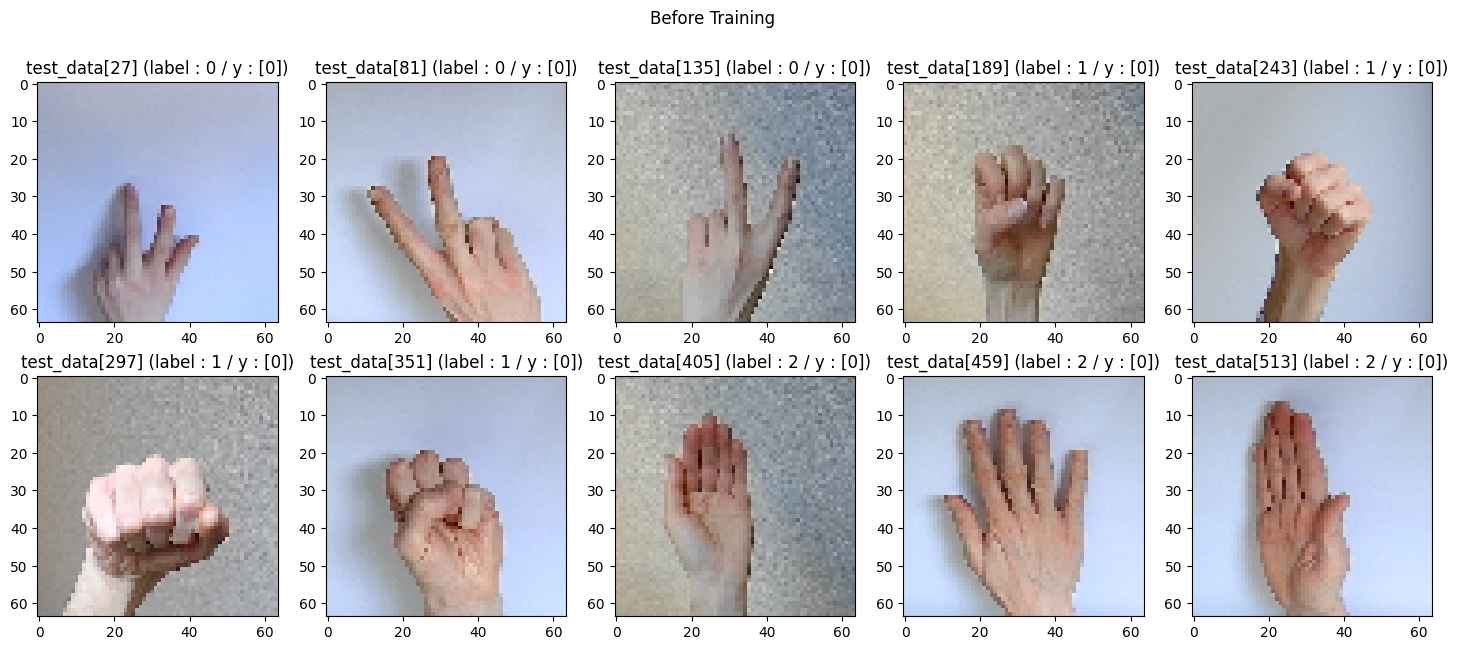

In [13]:
# 학습 전 모델의 예측 상태를 확인합니다.
# 아직 RPS 데이터에 맞게 충분히 학습되지 않았기 때문에 틀리는 예측이 많을 수 있습니다.
y_out = qat_model.predict(test_data)

# softmax 출력 3개 중 가장 큰 값의 위치를 예측 클래스로 선택합니다.
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))

# 학습 전 예측 결과를 그림으로 확인합니다.
Make_Result_Plot("Before Training", test_data, test_labels, y_max)


### 콜백 설정

In [14]:
# 학습 중 가장 성능이 좋은 모델을 저장하기 위한 설정입니다.
# h5 파일에는 QAT가 적용된 Keras 모델이 저장됩니다.
savedModelName = 'RPS_PreTrained_ResNet_Augmentation_QAT.h5'

callbacks = [
    # save_best_only=True: 검증 성능이 가장 좋을 때만 저장합니다.
    keras.callbacks.ModelCheckpoint(savedModelName,
                                    save_best_only=True)
]


### 모델 학습

In [32]:
%%time
# 모델 학습
# train_gen은 ImageDataGenerator가 만든 변형 이미지를 계속 공급합니다.
# epochs=10은 전체 학습 데이터를 10번 반복해서 본다는 뜻입니다.
# validation_data는 학습에 쓰지 않은 test_data로 성능을 확인합니다.
history = qat_model.fit(train_gen, epochs=10,
                    callbacks=callbacks,
                    validation_data=(test_data, test_labels))


Epoch 1/10


I0000 00:00:1782022407.646043 1285356 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1782022427.315816 1306478 service.cc:153] XLA service 0x7f2d5c039f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782022427.315861 1306478 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1782022427.596614 1306478 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782022428.244242 1306478 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 [==============================] - ETA: 0s - loss: 0.8209 - accuracy: 0.6059

/hai/home/lsh/RP2-RPS-QAT-Lab/.venv/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


68/68 [==============================] - 106s 822ms/step - loss: 0.8209 - accuracy: 0.6059 - val_loss: 0.4343 - val_accuracy: 0.8422
Epoch 2/10
68/68 [==============================] - 54s 789ms/step - loss: 0.3847 - accuracy: 0.8412 - val_loss: 0.1617 - val_accuracy: 0.9339
Epoch 3/10
68/68 [==============================] - 54s 801ms/step - loss: 0.1972 - accuracy: 0.9240 - val_loss: 0.0993 - val_accuracy: 0.9578
Epoch 4/10
68/68 [==============================] - 52s 767ms/step - loss: 0.1508 - accuracy: 0.9420 - val_loss: 0.1630 - val_accuracy: 0.9339
Epoch 5/10
68/68 [==============================] - 52s 765ms/step - loss: 0.1136 - accuracy: 0.9576 - val_loss: 0.1387 - val_accuracy: 0.9450
Epoch 6/10
68/68 [==============================] - 57s 834ms/step - loss: 0.1183 - accuracy: 0.9622 - val_loss: 0.0656 - val_accuracy: 0.9725
Epoch 7/10
68/68 [==============================] - 66s 967ms/step - loss: 0.0810 - accuracy: 0.9756 - val_loss: 0.0416 - val_accuracy: 0.9835
Epoch 8/1

> ### Ploting : Cost/Training Count

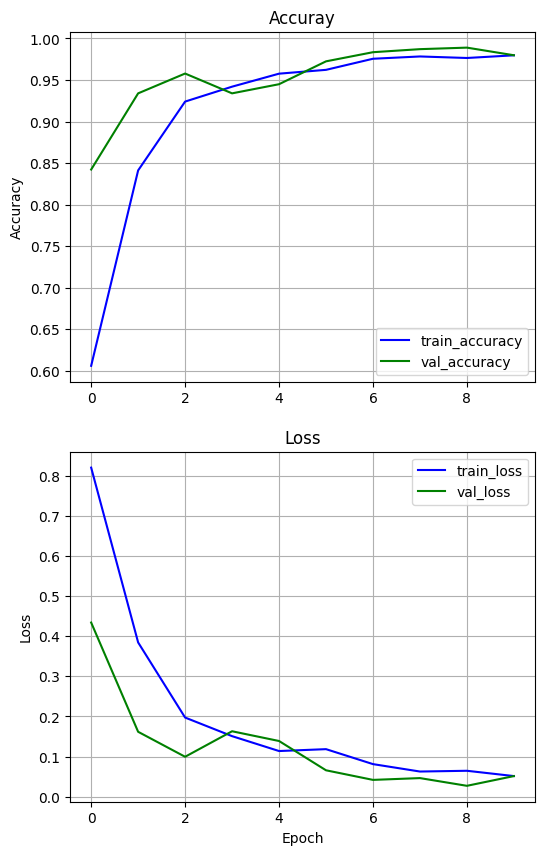

In [33]:
# 학습 과정 시각화
# 위 그래프: 정확도 변화
# 아래 그래프: 손실(loss) 변화
# train과 validation이 함께 좋아지면 학습이 잘 되고 있는 것입니다.

plt.figure(figsize=(6, 10))

# 정확도 그래프
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(history.history['val_accuracy'], 'g', label='val_accuracy')
# plt.ylim([0,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

# 손실 그래프
plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(history.history['loss'], 'b', label='train_loss')
plt.plot(history.history['val_loss'], 'g', label='val_loss')
# plt.ylim([0,5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()


### best 모델 로딩 및 테스트

In [34]:
# 저장된 best 모델 다시 불러오기
# QAT 모델에는 QuantizeWrapperV2 같은 특수 layer가 들어 있습니다.
# 그래서 일반 load_model이 아니라 quantize_scope 안에서 불러와야 합니다.
from tensorflow_model_optimization.quantization.keras import quantize_scope

try:
    # quantize_scope() 안에서 모델을 로드하면 QAT 관련 사용자 정의 객체를 인식합니다.
    with quantize_scope():
        model_best = keras.models.load_model(savedModelName)
except ValueError as e:
    print(f"Model load failed: {e}")


18/18 [==============================] - 8s 333ms/step


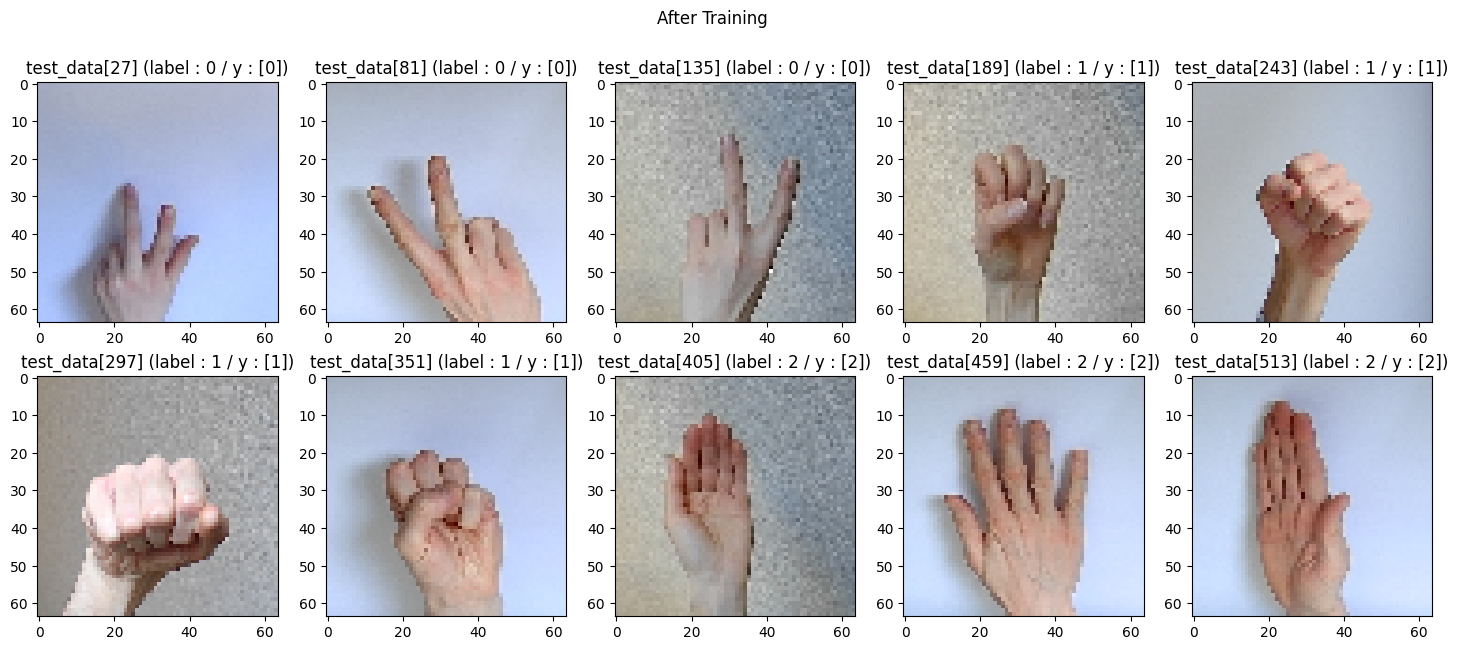

In [35]:
# 학습 후 best 모델의 예측 결과를 확인합니다.
y_out = model_best.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)


### best 모델 백업

In [36]:
# 학습된 모델과 TFLite 파일을 저장할 위치를 정합니다.
# 학생용 저장소에서는 results/ 폴더에 결과를 저장합니다.
# results/는 .gitignore에 들어 있으므로 큰 모델 파일이 실수로 push되지 않습니다.
from pathlib import Path

try:
    repo_root = get_git_root()
except NameError:
    repo_root = None

if repo_root is None:
    repo_root = Path.cwd()

save_dir = str(repo_root / "results") + "/"
Path(save_dir).mkdir(parents=True, exist_ok=True)
print("save_dir:", save_dir)


save_dir: /hai/home/lsh/RP2-RPS-QAT-Lab/results/


In [37]:
# 학습된 best Keras 모델(.h5)을 results/ 폴더로 복사합니다.
# results/는 .gitignore에 포함되어 있어 GitHub에는 올라가지 않습니다.
import shutil
from pathlib import Path

src_model = Path(savedModelName)
dst_model = Path(save_dir) / savedModelName

if src_model.exists():
    shutil.copy2(src_model, dst_model)
    print("Saved best model to:", dst_model)
else:
    print("Model file not found:", src_model)


Saved best model to: /hai/home/lsh/RP2-RPS-QAT-Lab/results/RPS_PreTrained_ResNet_Augmentation_QAT.h5


### 초보자 핵심 정리

여기까지의 핵심은 다음과 같습니다.

1. `RPS_Dataset`에서 가위/바위/보 이미지를 읽어 `64 x 64 x 3` 배열로 만듭니다.
2. ImageNet으로 미리 학습된 `ResNet50`을 가져와 마지막 분류기를 3개 클래스로 바꿉니다.
3. 데이터 보강으로 조명, 위치, 회전, 크기 변화에 강하게 만듭니다.
4. QAT를 적용해 TFLite 양자화 후에도 정확도가 유지되도록 학습합니다.
5. 최종 `.tflite` 파일을 라즈베리파이에 복사해 실시간 손 모양 인식에 사용합니다.

주의: ResNet50은 실습 비교용으로 좋지만 라즈베리파이에서는 DenseNet121 또는 MobileNet 계열보다 느릴 수 있습니다. 모델 정확도뿐 아니라 FPS와 지연 시간도 함께 비교해야 합니다.


### LiteRT 모델로 변환

In [44]:
# Keras QAT 모델을 TFLite 모델로 변환합니다.
# TFLite는 라즈베리파이 같은 엣지 장치에서 실행하기 좋은 모델 형식입니다.

converter = tf.lite.TFLiteConverter.from_keras_model(model_best)

# Optimize.DEFAULT: dynamic range quantization
# weight는 int8로, activation은 runtime에 dynamic하게 양자화
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 실제 변환 실행. 결과는 bytes 형태의 tflite_model입니다.
tflite_model = converter.convert()
print(f"✅ Conversion complete! Size: {len(tflite_model)/1024/1024:.2f} MB")

INFO:tensorflow:Assets written to: /hai/home/lsh/.claude_temp/tmpfrsha5q_/assets


INFO:tensorflow:Assets written to: /hai/home/lsh/.claude_temp/tmpfrsha5q_/assets
/hai/home/lsh/RP2-RPS-QAT-Lab/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782092186.880338 1790707 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782092186.880404 1790707 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782092186.880875 1790707 reader.cc:83] Reading SavedModel from: /hai/home/lsh/.claude_temp/tmpfrsha5q_
I0000 00:00:1782092186.931200 1790707 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782092186.931268 1790707 reader.cc:147] Reading SavedModel debug info (if present) from: /hai/home/lsh/.claude_temp/tmpfrsha5q_
I0000 00:00:1782092187.331818 1790707 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782092189.404118 1790707 loader.cc:220] Running initializ

✅ Conversion complete! Size: 23.49 MB


### LiteRT 모델을 파일로 저장

In [45]:
# 라즈베리파이에 가져갈 최종 TFLite 파일 이름입니다.
# 이 파일을 Raspberry Pi에서 tflite_runtime 또는 LiteRT로 실행합니다.
# DenseNet 버전과 헷갈리지 않도록 ResNet50 이름을 넣었습니다.
tfliteFileName = 'RPS_PreTrained_ResNet50_Augmentation_QAT.tflite'


In [46]:
# 변환된 TFLite 모델을 파일로 저장합니다.
# ResNet50은 DenseNet121보다 파일 크기가 커질 수 있습니다.
# 저장 후 실제 파일 크기와 라즈베리파이 추론 속도를 반드시 확인하세요.
open(save_dir + tfliteFileName, 'wb').write(tflite_model)


24626776

## Tier 1 Pruning Ablation (Unstructured vs Structured)

| 방법 | 단위 | 프로토콜 |
|---|---|---|
| **Unstructured** | 개별 weight | magnitude pruning → fine-tune |
| **Structured** | 채널 | **Network Slimming**: L1 γ sparsity 학습 → channel prune → fine-tune |

아래 **셀을 분리**해 실행합니다.
1. 공통 설정
2. Unstructured ablation
3. Structured ablation (Network Slimming)
4. 결과 비교 그래프

**Tier 1 한계:** shape는 그대로 → TFLite 파일 크기는 거의 변하지 않을 수 있습니다.

> 실행 전: `train_gen`, `train_data`, `test_data`, `test_labels` 준비 필요 (데이터 로딩 셀).  
> Best model은 `results/RPS_PreTrained_ResNet_Augmentation_QAT.h5` 로 자동 로드됩니다.

In [47]:
# === Tier 1 ablation 공통 설정 ===
import sys
from pathlib import Path

_repo = Path.cwd()
if not (_repo / "utils").exists() and (_repo.parent / "utils").exists():
    _repo = _repo.parent
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

import importlib
import utils.pruning_ablation as _pruning_ablation
importlib.reload(_pruning_ablation)
from utils.pruning_ablation import (
    run_unstructured_ablation,
    run_structured_ablation,
    results_to_dataframe,
)

# --- Unstructured 설정 ---
UNSTRUCTURED_RATIOS = [0.3]
UNSTRUCTURED_FT_EPOCHS = 3

# --- Structured (Network Slimming) 설정 ---
STRUCTURED_PERCENTS = [0.3]
L1_SPARSITY_EPOCHS = 3      # γ L1 학습 epoch 수
L1_LAMBDA = 1e-4            # γ L1 penalty 강도
#   ↑ 핵심: 1e-5(이전)→1e-4로 올림. 이전 버전은 BN이 frozen 상태라 gradient가 흐르지
#     않아 sparsity가 전혀 생기지 않았음. 지금은 BN을 L1 단계에만 일시 해제해서 γ가
#     실제로 0에 가까워지고, 그 채널을 잘라내도 정확도 손실이 작아집니다.
L1_LEARNING_RATE = 1e-4     # L1 단계 learning rate (γ를 충분히 밀어내려면 1e-5보다 커야 함)
STRUCTURED_FT_EPOCHS = 10   # prune 후 fine-tune epoch 수
L1_BATCH_SIZE = 32          # L1 단계 batch (train_data 직접 사용, augmentation 없음)

# 저장 위치
try:
    ABLATION_SAVE_DIR = save_dir
except NameError:
    ABLATION_SAVE_DIR = str(_repo / "results") + "/"
Path(ABLATION_SAVE_DIR).mkdir(parents=True, exist_ok=True)
print("Ablation save dir:", ABLATION_SAVE_DIR)

# --- Best model (하드코딩) ---
BEST_MODEL_PATH = _repo / "results" / "RPS_PreTrained_ResNet_Augmentation_QAT.h5"
if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"Best model not found: {BEST_MODEL_PATH}")

from tensorflow_model_optimization.quantization.keras import quantize_scope
from tensorflow_model_optimization.python.core.keras.compat import keras

print("Best model path:", BEST_MODEL_PATH)

with quantize_scope():
    model_best = keras.models.load_model(str(BEST_MODEL_PATH))

def load_fresh_model():
    with quantize_scope():
        return keras.models.load_model(str(BEST_MODEL_PATH))

_, baseline_acc = model_best.evaluate(test_data, test_labels, verbose=0)
print(f"Baseline accuracy: {baseline_acc:.4f}")
print(f"Baseline params:   {model_best.count_params():,}")

Ablation save dir: /hai/home/lsh/RP2-RPS-QAT-Lab/results/
Best model path: /hai/home/lsh/RP2-RPS-QAT-Lab/results/RPS_PreTrained_ResNet_Augmentation_QAT.h5
Baseline accuracy: 0.9853
Baseline params:   23,647,287


### Unstructured pruning (magnitude)

In [48]:
# Unstructured ablation: magnitude pruning → fine-tune → .h5/.tflite 저장
unstructured_results = run_unstructured_ablation(
    load_model_fn=load_fresh_model,
    train_gen=train_gen,
    test_data=test_data,
    test_labels=test_labels,
    ratios=UNSTRUCTURED_RATIOS,
    finetune_epochs=UNSTRUCTURED_FT_EPOCHS,
    save_dir=ABLATION_SAVE_DIR,
)

df_unstructured = results_to_dataframe(unstructured_results)
df_unstructured


=== Unstructured pruning: sparsity=30% ===
  before fine-tune: val_acc=0.9853
Epoch 1/3
68/68 [==============================] - 110s 1s/step - loss: 0.0764 - accuracy: 0.9756 - val_loss: 0.0299 - val_accuracy: 0.9872
Epoch 2/3
68/68 [==============================] - 68s 995ms/step - loss: 0.0441 - accuracy: 0.9816 - val_loss: 0.0290 - val_accuracy: 0.9872
Epoch 3/3
68/68 [==============================] - 67s 992ms/step - loss: 0.0432 - accuracy: 0.9853 - val_loss: 0.0286 - val_accuracy: 0.9853


/hai/home/lsh/RP2-RPS-QAT-Lab/.venv/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


INFO:tensorflow:Assets written to: /hai/home/lsh/.claude_temp/tmpn22yryxm/assets


INFO:tensorflow:Assets written to: /hai/home/lsh/.claude_temp/tmpn22yryxm/assets
/hai/home/lsh/RP2-RPS-QAT-Lab/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782092518.138900 1790707 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782092518.138948 1790707 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782092518.139365 1790707 reader.cc:83] Reading SavedModel from: /hai/home/lsh/.claude_temp/tmpn22yryxm
I0000 00:00:1782092518.197753 1790707 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782092518.197778 1790707 reader.cc:147] Reading SavedModel debug info (if present) from: /hai/home/lsh/.claude_temp/tmpn22yryxm
I0000 00:00:1782092518.471534 1790707 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782092520.028647 1790707 loader.cc:220] Running initializ

,method,ratio,acc_before_ft,acc_after_ft,weight_sparsity,channel_prune_ratio,params,h5_path,tflite_path,tflite_size_mb
0,unstructured,0.3,0.985321,0.985321,0.0,0.0,23647287,/hai/home/lsh/RP2-RPS-QAT-Lab/results/pruned_u...,/hai/home/lsh/RP2-RPS-QAT-Lab/results/pruned_u...,23.49


### Structured pruning (Network Slimming)

1. BN `γ`에 L1 sparsity 학습 (`L1_SPARSITY_EPOCHS`)
2. `|γ|` 작은 bottleneck 채널 제거 (mask)
3. Fine-tune (`STRUCTURED_FT_EPOCHS`)

### 결과 비교 그래프

위 두 셀(`df_unstructured`, `df_structured`) 실행 후 아래 셀에서 합쳐서 시각화합니다.

## Tier 3 Structured Rebuild (compact network)

**한 번에 끝내는 structured pruning 파이프라인:**

1. 원본 QAT 모델 로드
2. L1 γ sparsity 학습
3. `|γ|` 기준 channel plan + **source에 mask 적용** (transfer 정합성)
4. slim ResNet50 rebuild + weight transfer
5. **fine-tune 10 epoch** → `.h5` / `.tflite` 저장

> L1 직후 ~95%는 **full-width 모델** accuracy입니다. mask 적용 후에는 일시적으로 떨어질 수 있고, transfer 직후 slim 모델은 masked source와 비슷해야 정상입니다.

In [51]:
# === Tier 3: L1 → channel plan → rebuild → fine-tune ===
import importlib
import utils.structured_rebuild as _structured_rebuild
importlib.reload(_structured_rebuild)
from utils.structured_rebuild import run_structured_rebuild

# --- Tier 3 설정 ---
TIER3_CHANNEL_PERCENT = 0.3
TIER3_L1_EPOCHS = L1_SPARSITY_EPOCHS
TIER3_L1_LAMBDA = L1_LAMBDA
TIER3_L1_LEARNING_RATE = L1_LEARNING_RATE
TIER3_FT_EPOCHS = 10
TIER3_TAG = f"channel{int(TIER3_CHANNEL_PERCENT * 100):02d}"

slim_model, rebuild_info = run_structured_rebuild(
    load_model_fn=load_fresh_model,
    train_gen=train_gen,
    test_data=test_data,
    test_labels=test_labels,
    channel_percent=TIER3_CHANNEL_PERCENT,
    l1_sparsity_epochs=TIER3_L1_EPOCHS,
    l1_lambda=TIER3_L1_LAMBDA,
    l1_learning_rate=TIER3_L1_LEARNING_RATE,
    finetune_epochs=TIER3_FT_EPOCHS,
    save_dir=ABLATION_SAVE_DIR,
    tag=TIER3_TAG,
    train_data=train_data,
    train_labels=train_labels,
    batch_size=L1_BATCH_SIZE,
)

print("\n=== Rebuild summary ===")
print(f"source params:      {rebuild_info['source_params']:,}")
print(f"slim params:        {rebuild_info['params']:,}")
print(f"channel prune ratio:{rebuild_info['channel_prune_ratio']:.1%}")
print(f"masked source acc: {rebuild_info.get('acc_masked_source', 'n/a')}")
print(f"acc (transfer):     {rebuild_info['acc_after_transfer']:.4f}")
print(f"acc (fine-tune):    {rebuild_info['acc_after_ft']:.4f}")
if rebuild_info.get("tflite_size_mb"):
    print(f"TFLite size:        {rebuild_info['tflite_size_mb']} MB")
    print(f"saved h5:           {rebuild_info['h5_path']}")
    print(f"saved tflite:       {rebuild_info['tflite_path']}")

rebuild_info


=== Tier 3 Structured Rebuild: channel=30% ===
  Step 1/4: L1 sparsity training (3 epochs, lambda=0.0001, lr=0.0001)
  L1 training data: in-memory arrays (batch_size=32, no augmentation)
  BN unfrozen for L1 phase: 53/53 layers
  gamma tensors in trainable_variables: 53
Epoch 1/3
68/68 [==============================] - 144s 1s/step - loss: 0.2081 - accuracy: 0.9268 - val_loss: 0.0486 - val_accuracy: 0.9853
Epoch 2/3
68/68 [==============================] - 69s 1s/step - loss: 0.0252 - accuracy: 0.9917 - val_loss: 0.0699 - val_accuracy: 0.9798
Epoch 3/3
68/68 [==============================] - 69s 1s/step - loss: 0.0154 - accuracy: 0.9954 - val_loss: 0.0159 - val_accuracy: 0.9963
  L1 sparsity done: final val_acc=0.9963, L1_reg=3.078356
  Step 2/4: channel plan from |gamma| + apply masks
  channel prune ratio: 30.2%
  masked source (before rebuild): val_acc=0.3321
  Step 3/4: rebuild slim network + weight transfer
Channel plan: stem=44, blocks={'conv2_block1': (44, 44), 'conv2_block2'

/hai/home/lsh/RP2-RPS-QAT-Lab/.venv/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


INFO:tensorflow:Assets written to: /hai/home/lsh/.claude_temp/tmp3c7qaorw/assets


INFO:tensorflow:Assets written to: /hai/home/lsh/.claude_temp/tmp3c7qaorw/assets
W0000 00:00:1782094893.334443 1790707 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782094893.334499 1790707 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782094893.335004 1790707 reader.cc:83] Reading SavedModel from: /hai/home/lsh/.claude_temp/tmp3c7qaorw
I0000 00:00:1782094893.390394 1790707 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782094893.390439 1790707 reader.cc:147] Reading SavedModel debug info (if present) from: /hai/home/lsh/.claude_temp/tmp3c7qaorw
I0000 00:00:1782094893.612313 1790707 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782094894.900163 1790707 loader.cc:220] Running initialization op on SavedModel bundle at path: /hai/home/lsh/.claude_temp/tmp3c7qaorw
I0000 00:00:1782094895.237746 1790707 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1902924 microseconds.


  saved: /hai/home/lsh/RP2-RPS-QAT-Lab/results/rebuilt_structured_channel30.h5
  TFLite: 14.56 MB

=== Rebuild summary ===
source params:      23,647,287
slim params:        14,941,933
channel prune ratio:30.2%
masked source acc: 0.33211007714271545
acc (transfer):     0.3321
acc (fine-tune):    0.6422
TFLite size:        14.56 MB
saved h5:           /hai/home/lsh/RP2-RPS-QAT-Lab/results/rebuilt_structured_channel30.h5
saved tflite:       /hai/home/lsh/RP2-RPS-QAT-Lab/results/rebuilt_structured_channel30.tflite


{'channel_plan': {'stem': 44,
  'stem_idx': array([ 0,  1,  3,  4,  5,  7,  8, 10, 13, 14, 15, 16, 17, 18, 19, 20, 21,
         22, 23, 24, 25, 26, 29, 30, 34, 37, 38, 39, 40, 41, 42, 44, 45, 46,
         47, 49, 50, 51, 53, 54, 55, 58, 62, 63]),
  'blocks': {'conv2_block1': (44, 44),
   'conv2_block2': (44, 44),
   'conv2_block3': (44, 44),
   'conv3_block1': (89, 89),
   'conv3_block2': (89, 89),
   'conv3_block3': (89, 89),
   'conv3_block4': (89, 89),
   'conv4_block1': (179, 179),
   'conv4_block2': (179, 179),
   'conv4_block3': (179, 179),
   'conv4_block4': (179, 179),
   'conv4_block5': (179, 179),
   'conv4_block6': (179, 179),
   'conv5_block1': (358, 358),
   'conv5_block2': (358, 358),
   'conv5_block3': (358, 358)},
  'conv2_block1_idx1': array([ 1,  2,  3,  4,  8, 11, 12, 13, 14, 15, 16, 19, 21, 22, 25, 26, 27,
         29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 44, 45, 47, 49,
         50, 51, 52, 53, 54, 58, 59, 60, 61, 62]),
  'conv2_block1_idx2': array([ 0, 

In [50]:
# === Comprehensive Model Comparison: Tier1 vs Tier3 ===
# Baseline QAT, Tier1 Unstructured, Tier1 Structured, Tier3 Rebuilt

import os

def evaluate_tflite_model(tflite_model_path, test_data, test_labels, verbose=1):
    """TFLite int8 모델의 정확도 측정."""
    import tensorflow as tf
    import numpy as np
    
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()
    
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    if verbose:
        print(f"    TFLite input: {input_details[0]['shape']}, dtype={input_details[0]['dtype'].__name__}")
    
    predictions = []
    for i, img in enumerate(test_data):
        if verbose and i % max(1, len(test_data) // 5) == 0 and i > 0:
            print(f"      processed {i}/{len(test_data)}")
        
        input_data = np.expand_dims(img, axis=0).astype(np.float32)
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        
        output_data = interpreter.get_tensor(output_details[0]['index'])
        pred = np.argmax(output_data[0])
        predictions.append(pred)
    
    predictions = np.array(predictions)
    accuracy = float(np.mean(predictions == test_labels))
    return accuracy


# 4가지 모델: Baseline, Tier1 Unstructured, Tier1 Structured, Tier3 Rebuilt
model_configs = {
    '0️⃣ baseline_QAT': {
        'h5': str(ABLATION_SAVE_DIR) + 'RPS_PreTrained_ResNet_Augmentation_QAT.h5',
        'tflite': str(ABLATION_SAVE_DIR) + 'RPS_PreTrained_ResNet50_Augmentation_QAT.tflite',
        'tier': 'Baseline',
    },
    '1️⃣ Tier1_Unstructured30': {
        'h5': str(ABLATION_SAVE_DIR) + 'pruned_unstructured_sparsity30.h5',
        'tflite': str(ABLATION_SAVE_DIR) + 'pruned_unstructured_sparsity30.tflite',
        'tier': 'Tier1 (shape 유지)',
    },
    '2️⃣ Tier1_Structured30': {
        'h5': str(ABLATION_SAVE_DIR) + 'pruned_structured_channel30.h5',
        'tflite': str(ABLATION_SAVE_DIR) + 'pruned_structured_channel30.tflite',
        'tier': 'Tier1 (shape 유지)',
    },
    '3️⃣ Tier3_Rebuilt30': {
        'h5': str(ABLATION_SAVE_DIR) + 'rebuilt_structured_channel30.h5',
        'tflite': str(ABLATION_SAVE_DIR) + 'rebuilt_structured_channel30.tflite',
        'tier': 'Tier3 (shape 축소)',
    },
}

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON: Baseline vs Tier1 vs Tier3")
print("="*80)

comparison_results = []

for model_name, paths in model_configs.items():
    print(f"\n{'-'*80}")
    print(f"{model_name} [{paths['tier']}]")
    print(f"{'-'*80}")
    
    result = {'model': model_name.split()[1], 'tier': paths['tier']}
    
    # 1. Keras float32 평가
    print(f"\n  1️⃣  Keras float32 모델:")
    try:
        with quantize_scope():
            keras_model = keras.models.load_model(paths['h5'])
        
        result['params_m'] = keras_model.count_params() / 1e6
        result['acc_keras'] = float(keras_model.evaluate(test_data, test_labels, verbose=0)[1])
        
        print(f"      ✓ Params: {result['params_m']:.2f}M")
        print(f"      ✓ Accuracy (float32): {result['acc_keras']:.4f}")
        
    except Exception as e:
        print(f"      ❌ Keras 로드 실패: {e}")
        continue
    
    # 2. TFLite int8 평가
    print(f"\n  2️⃣  TFLite int8 모델:")
    try:
        tflite_size_bytes = os.path.getsize(paths['tflite'])
        result['tflite_size_mb'] = tflite_size_bytes / (1024*1024)
        
        print(f"      ✓ 파일 크기: {result['tflite_size_mb']:.2f} MB")
        print(f"      ✓ 정확도 측정 중...")
        
        result['acc_tflite'] = evaluate_tflite_model(paths['tflite'], test_data, test_labels, verbose=0)
        
        print(f"      ✓ Accuracy (int8): {result['acc_tflite']:.4f}")
        
    except Exception as e:
        print(f"      ❌ TFLite 로드 실패: {e}")
        continue
    
    # 3. 통계
    result['acc_drop'] = result['acc_keras'] - result['acc_tflite']
    result['flops_approx_m'] = result['params_m'] * 2
    
    print(f"\n  📈 양자화 분석:")
    print(f"      ⊙ Accuracy drop: {result['acc_drop']:+.4f} (float32 → int8)")
    if result['acc_drop'] < 0.01:
        print(f"      ✅ QAT 효과 뛰어남! (손실 < 0.01)")
    elif result['acc_drop'] < 0.03:
        print(f"      ✓ QAT 효과 좋음 (손실 < 0.03)")
    else:
        print(f"      ⚠ 주의: 양자화 손실이 큼")
    
    comparison_results.append(result)


# 종합 비교 표
print(f"\n\n{'='*80}")
print("📋 COMPARISON TABLE (4 Models)")
print(f"{'='*80}\n")

df_comp = pd.DataFrame(comparison_results)
df_comp = df_comp[[
    'model', 'tier', 'params_m', 'tflite_size_mb',
    'acc_keras', 'acc_tflite', 'acc_drop'
]]

df_comp.columns = ['Model', 'Tier', 'Params (M)', 'TFLite Size (MB)',
                   'Acc (float32)', 'Acc (int8)', 'Drop']

print(df_comp.to_string(index=False))

# 상대 비교 (baseline 대비)
print(f"\n\n{'='*80}")
print("🎯 RELATIVE COMPARISON (vs Baseline)")
print(f"{'='*80}\n")

baseline = comparison_results[0]
for result in comparison_results:
    model_name = result['model']
    tier = result['tier']
    params_ratio = result['params_m'] / baseline['params_m']
    size_ratio = result['tflite_size_mb'] / baseline['tflite_size_mb']
    
    print(f"{model_name} [{tier}]:")
    print(f"  Params:    {params_ratio:6.1%} ({(params_ratio-1)*100:+6.1f}%)")
    print(f"  Size:      {size_ratio:6.1%} ({(size_ratio-1)*100:+6.1f}%)")
    print(f"  Accuracy:  float32={result['acc_keras']:.4f}, int8={result['acc_tflite']:.4f}")
    print()

display(df_comp)

COMPREHENSIVE MODEL COMPARISON: Baseline vs Tier1 vs Tier3

--------------------------------------------------------------------------------
0️⃣ baseline_QAT [Baseline]
--------------------------------------------------------------------------------

  1️⃣  Keras float32 모델:
      ✓ Params: 23.65M
      ✓ Accuracy (float32): 0.9853

  2️⃣  TFLite int8 모델:
      ✓ 파일 크기: 23.49 MB
      ✓ 정확도 측정 중...


/hai/home/lsh/RP2-RPS-QAT-Lab/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


      ✓ Accuracy (int8): 0.9853

  📈 양자화 분석:
      ⊙ Accuracy drop: +0.0000 (float32 → int8)
      ✅ QAT 효과 뛰어남! (손실 < 0.01)

--------------------------------------------------------------------------------
1️⃣ Tier1_Unstructured30 [Tier1 (shape 유지)]
--------------------------------------------------------------------------------

  1️⃣  Keras float32 모델:
      ✓ Params: 23.65M
      ✓ Accuracy (float32): 0.9853

  2️⃣  TFLite int8 모델:
      ✓ 파일 크기: 23.49 MB
      ✓ 정확도 측정 중...
      ✓ Accuracy (int8): 0.9872

  📈 양자화 분석:
      ⊙ Accuracy drop: -0.0018 (float32 → int8)
      ✅ QAT 효과 뛰어남! (손실 < 0.01)

--------------------------------------------------------------------------------
2️⃣ Tier1_Structured30 [Tier1 (shape 유지)]
--------------------------------------------------------------------------------

  1️⃣  Keras float32 모델:
      ✓ Params: 23.65M
      ✓ Accuracy (float32): 0.9358

  2️⃣  TFLite int8 모델:
      ✓ 파일 크기: 23.49 MB
      ✓ 정확도 측정 중...
      ✓ Accuracy (int8): 0.9376

 

,Model,Tier,Params (M),TFLite Size (MB),Acc (float32),Acc (int8),Drop
0,baseline_QAT,Baseline,23.647287,23.485924,0.985321,0.985321,3.609089e-09
1,Tier1_Unstructured30,Tier1 (shape 유지),23.647287,23.485924,0.985321,0.987156,-1.834859e-03
2,Tier1_Structured30,Tier1 (shape 유지),23.647287,23.485924,0.935780,0.937615,-1.834869e-03
3,Tier3_Rebuilt30,Tier3 (shape 축소),14.941933,14.563644,0.733945,0.722936,1.100917e-02
